In [1]:
from __future__ import annotations

import numpy as np
import umap
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from datasets import Dataset
from protein_search_evals.datasets.pfam import Pfam20Dataset

/homes/abrace/.conda/envs/protein_search_evals/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
data_dir = '../../data/pfam'
dataset = Pfam20Dataset(data_dir)
sequences = dataset.load_sequences()
families = dataset.load_clusters()

# Remove the PF07719.XXX format
families = {pfam_id.split('.')[0]: members for pfam_id, members in families.items()}

Loading Pfam20 families metadata from ../../data/pfam/pfam20_seed-42/sequences.fasta
Loading Pfam20 families metadata from ../../data/pfam/pfam20_seed-42/families.json


In [3]:
# Pfam ids for tetratricopeptide repeats
pfam_ids = ['PF07719', 'PF13181']

In [4]:
# Get the uniprot ids 
pfam_members = []
for pfam_id in pfam_ids:
    pfam_members.extend(families[pfam_id])

In [5]:
pfam_members

['A0A2K3NZE8.1',
 'A0A368V2K3.1',
 'A0A931J432.1',
 'A0A0W0U997.1',
 'A0A841ELD5.1',
 'M5S3J4.1',
 'A0A4P9XYN7.1',
 'A0A4Y7JYP1.1',
 'A0A4Y2A677.1',
 'A0A814B6U2.1',
 'A0A6J5CXT0.1',
 'A0A1Y1Z659.1',
 'A0A5A7SS00.1',
 'A0A5D0S2H4.1',
 'A0A061J8C5.1',
 'Q7VL90.1',
 'A0A7V8NX06.1',
 'A0A8J9RST8.1',
 'A0A8H7YYM5.1',
 'A0A0P8Y878.1',
 'A0A2C5XZI6.1',
 'A0A674AW88.1',
 'A0A4Q2UQB3.1',
 'Q54D58.1',
 'A0A2R7K0M8.1',
 'A0A0R3U429.1',
 'A0A1V4JJQ8.1',
 'A0A5E4M8G7.1',
 'A0A915CN71.1',
 'A0A495J7S9.1',
 'H4FC98.1',
 'A0A8X8W716.1',
 'A0A2R6XHF2.1',
 'G3HDF6.1',
 'F0UJX5.1',
 'A0A835K0Z4.1',
 'B6JFE0.1',
 'A0A7K8YUM0.1',
 'A5E088.1',
 'A0A8J4SKS5.1']

In [6]:
# Get the embeddings
dataset = Dataset.load_from_disk('./embeddings/esm2-3B_pfam20_seed-42/embeddings/b80c1e9e-a45a-46e0-8da9-77b7d404a159/')
dataset.set_format('numpy', columns=['embeddings'])

In [7]:
dataset

Dataset({
    features: ['embeddings', 'sequences', 'tags'],
    num_rows: 351980
})

In [8]:
embeddings = np.array(dataset['embeddings'])
embeddings.shape

(351980, 2560)

In [9]:
tags = dataset['tags']
pfam_tag_indices = [tags.index(pfam_id) for pfam_id in pfam_members]

In [10]:
pfam_tag_indices

[109438,
 298579,
 162467,
 201565,
 136854,
 232340,
 34343,
 105509,
 69283,
 47686,
 284561,
 33733,
 105031,
 147715,
 69119,
 160236,
 299733,
 110082,
 15664,
 138582,
 28140,
 335173,
 211024,
 349474,
 135852,
 78745,
 312830,
 65681,
 73191,
 173427,
 257864,
 129658,
 122595,
 301014,
 19847,
 127675,
 161285,
 346155,
 19433,
 67114]

In [11]:
def plot_umap_with_highlights(
    embeddings, 
    highlight_indices=None, 
    n_neighbors=15, 
    min_dist=0.1, 
    random_state=42, 
    pca_components=None
):
    """
    Plot UMAP projection of embeddings with special indices as stars.

    Parameters
    ----------
    embeddings : np.ndarray
        Shape (n_samples, n_features) array of embeddings.
    highlight_indices : list[int] or np.ndarray
        Indices of samples to highlight with stars.
    n_neighbors : int
        UMAP parameter, number of neighbors for manifold learning.
    min_dist : float
        UMAP parameter, minimum distance for low-dimensional embedding.
    random_state : int
        Seed for reproducibility.
    pca_components : int or None
        If not None, reduce dimensionality with PCA before UMAP.
    """
    X = embeddings

    # Optional PCA step
    if pca_components is not None and embeddings.shape[1] > pca_components:
        pca = PCA(n_components=pca_components, random_state=random_state)
        X = pca.fit_transform(embeddings)
        print(f"PCA reduced dimensions from {embeddings.shape[1]} → {X.shape[1]}")

    # Run UMAP
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, random_state=random_state)
    embedding_2d = reducer.fit_transform(X)

    # Separate points
    if highlight_indices is None:
        highlight_indices = []
    highlight_indices = np.array(highlight_indices, dtype=int)

    normal_mask = np.ones(embeddings.shape[0], dtype=bool)
    normal_mask[highlight_indices] = False

    # Plot
    plt.figure(figsize=(8, 6))
    plt.scatter(
        embedding_2d[normal_mask, 0],
        embedding_2d[normal_mask, 1],
        s=20,
        c="lightgray",
        alpha=0.7,
        label="Other points"
    )

    if len(highlight_indices) > 0:
        plt.scatter(
            embedding_2d[highlight_indices, 0],
            embedding_2d[highlight_indices, 1],
            s=80,
            c="red",
            marker="*",
            edgecolor="black",
            linewidth=0.8,
            label="Highlighted"
        )

    plt.title("UMAP projection of embeddings", fontsize=14)
    plt.legend()
    plt.tight_layout()
    plt.show()

PCA reduced dimensions from 2560 → 50


/homes/abrace/.conda/envs/protein_search_evals/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


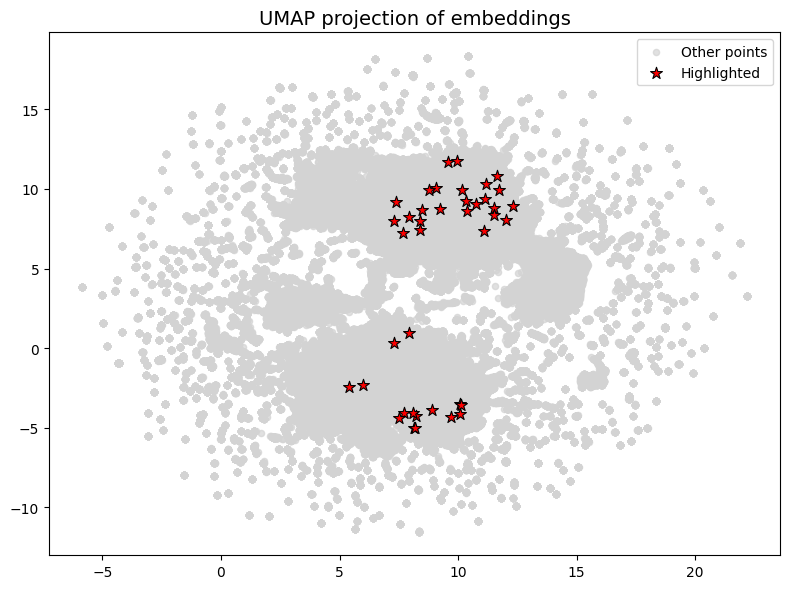

In [12]:
plot_umap_with_highlights(embeddings, highlight_indices=pfam_tag_indices, pca_components=50)